In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [83]:
csv_path=Path(r"C:\Users\ASUS\OneDrive\Desktop\data scicne fayllar\customer_churn_dataset-testing-master.csv")
df=pd.read_csv(csv_path)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [84]:
csv_path_1=Path(r"C:\Users\ASUS\OneDrive\Desktop\data scicne fayllar\customer_churn_dataset-training-master.csv")
df1=pd.read_csv(csv_path_1)
df1

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [85]:
df2 = pd.concat([df, df1], axis=0,ignore_index=True)
df2

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.00,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.00,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.00,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.00,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.00,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
505203,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
505204,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
505205,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [86]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


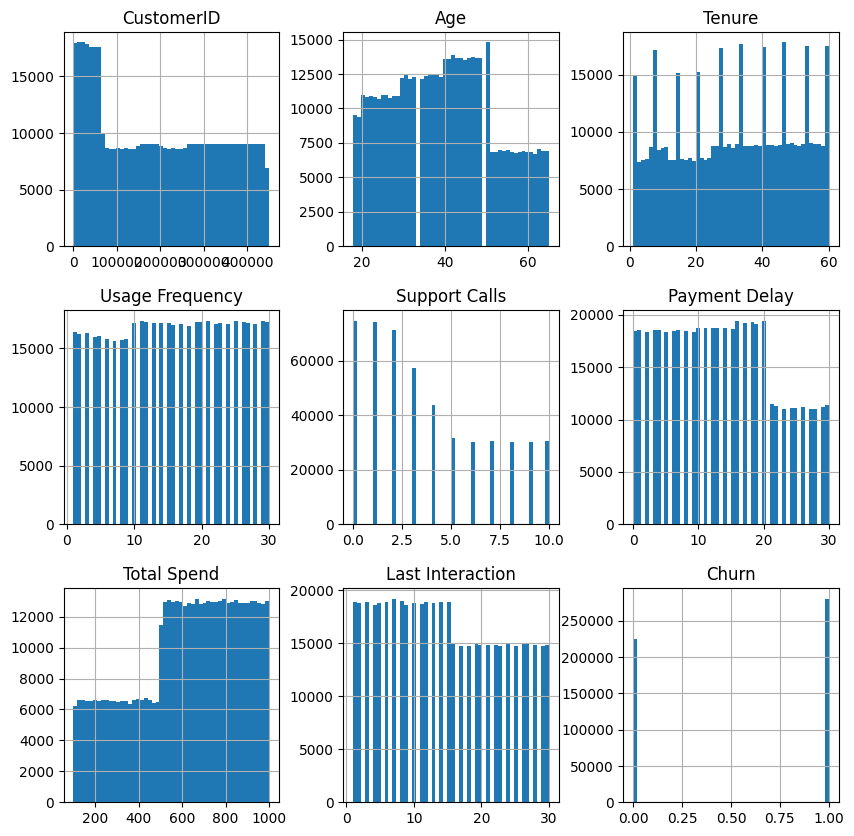

In [87]:
df2.hist(bins=50,figsize=(10,10))
plt.show()

In [88]:
#df2["Usage Frequency"].value_counts().sort_index()

In [89]:
# nan_rows = df[df['Age'].isna()]
# nan_rows.sum()

Outlier deyerlerin tapilmasi


In [90]:
numeric_cols = ["Tenure", "Usage Frequency", "Total Spend", "Last Interaction"]

for col in numeric_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df2 = df2[(df2[col] >= lower) & (df2[col] <= upper)]
df2

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.00,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.00,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.00,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.00,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.00,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
505203,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
505204,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
505205,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


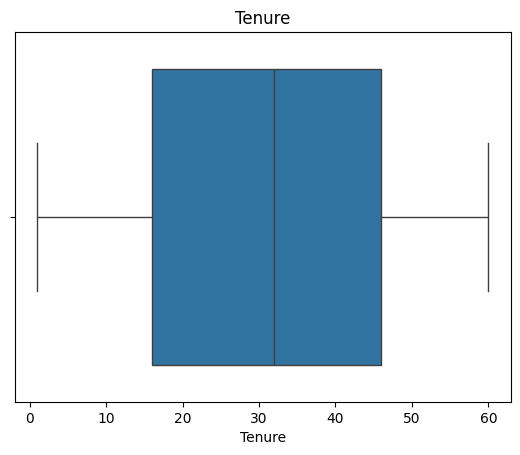

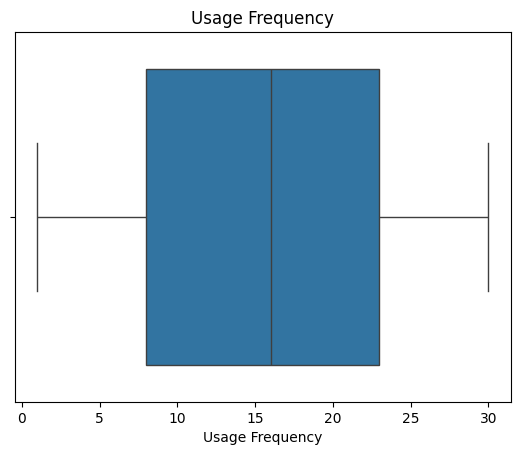

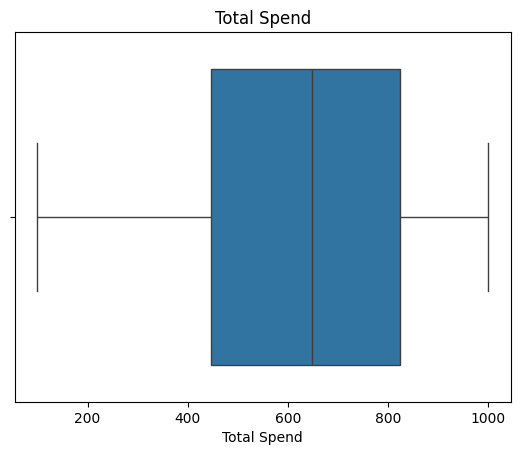

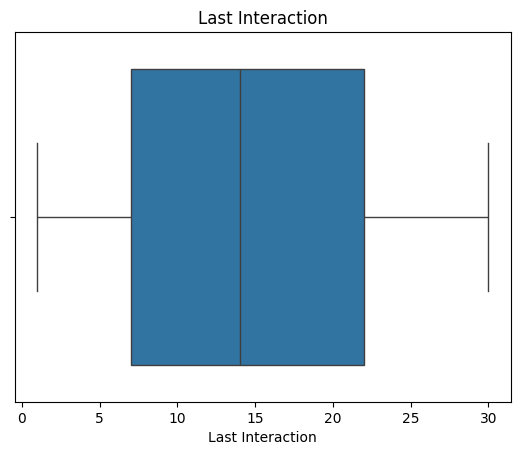

In [91]:
import seaborn as sns
for col in ["Tenure", "Usage Frequency", "Total Spend", "Last Interaction"]:
    sns.boxplot(x=df2[col])
    plt.title(col)
    plt.show()

target ve pred.. 

In [92]:
X= df2.drop("Churn", axis=1)
y=df2["Churn"]

In [93]:
X.select_dtypes(include=["float64"]).columns
X.select_dtypes(include=["object"]).columns

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

pipeline 

In [94]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

num_cols=['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
          'Payment Delay', 'Total Spend', 'Last Interaction']
cat_cols=['Gender', 'Subscription Type', 'Contract Length']

num_pipeline=Pipeline([
    # ("imp",SimpleImputer(strategy='median')),(data temizdi)
    ("scl", StandardScaler())
])
cat_pipeline=Pipeline([
    # ('imp', SimpleImputer(strategy='most_frequent')),(data temizdi)
    ('scl', OneHotEncoder(sparse_output=False,handle_unknown='ignore')) 
])

preprocessing=ColumnTransformer([
    ("Num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols),
])

X_arr = preprocessing.fit_transform(X)
X_tr = pd.DataFrame(X_arr, columns=preprocessing.get_feature_names_out())
X_tr


,Num__Age,Num__Tenure,Num__Usage Frequency,Num__Support Calls,Num__Payment Delay,Num__Total Spend,Num__Last Interaction,cat__Gender_Female,cat__Gender_Male,cat__Subscription Type_Basic,cat__Subscription Type_Premium,cat__Subscription Type_Standard,cat__Contract Length_Annual,cat__Contract Length_Monthly,cat__Contract Length_Quarterly
0,-1.397268,-0.368409,-0.198951,0.053192,1.597784,-0.089976,-0.651766,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.102271,-0.194369,1.425308,1.010558,-0.058790,-0.147044,0.626074,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.575809,-0.252383,-0.663026,-0.585052,1.834437,0.558160,0.742241,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.371268,-1.296620,-0.430988,0.372314,0.414517,-1.581911,0.393740,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.049348,1.546026,0.961234,1.648801,-1.360383,-0.354937,0.393740,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505201,0.181194,1.313973,-0.082933,-0.904173,-1.242057,0.392580,-0.767933,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
505202,-1.160499,-1.354633,-0.314970,-0.904173,0.769497,0.510793,-1.464937,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
505203,-1.081576,0.211723,1.309289,-0.904173,-1.005403,1.456215,-0.651766,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
505204,-0.923729,1.371986,-0.198951,-0.585052,-1.597037,-0.071428,-1.464937,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [95]:
X.shape , y.shape

((505206, 11), (505206,))

train ve teste bolme

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
 test_size=0.2)

LogisticRegression

In [101]:
from sklearn.linear_model import LogisticRegression
full_pipeline = Pipeline([
	("cleaning", preprocessing),
	("model", LogisticRegression())
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 1.], shape=(101042,))

In [ ]:
y_test.to_numpy()

array([1., 1., 0., ..., 0., 1., 1.], shape=(101042,))

In [107]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8484095722570812


In [108]:
df2["Churn"].value_counts()

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

RandomForestClassifier


In [111]:
from sklearn.ensemble import RandomForestClassifier
full_pipeline = Pipeline([
	("cleaning", preprocessing),
	("model",RandomForestClassifier())
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 1., 1.], shape=(101042,))

In [112]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9355020684467845


In [117]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),  # transformer
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train
full_pipeline.fit(X_train, y_train)

# Predict
y_pred = full_pipeline.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 1., 1.], shape=(101042,))

In [119]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.9356406246907226
